<a href="https://colab.research.google.com/github/Ishaanjain21/Experiment1.3/blob/main/Final_project_semester_mini_project_air_quality_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

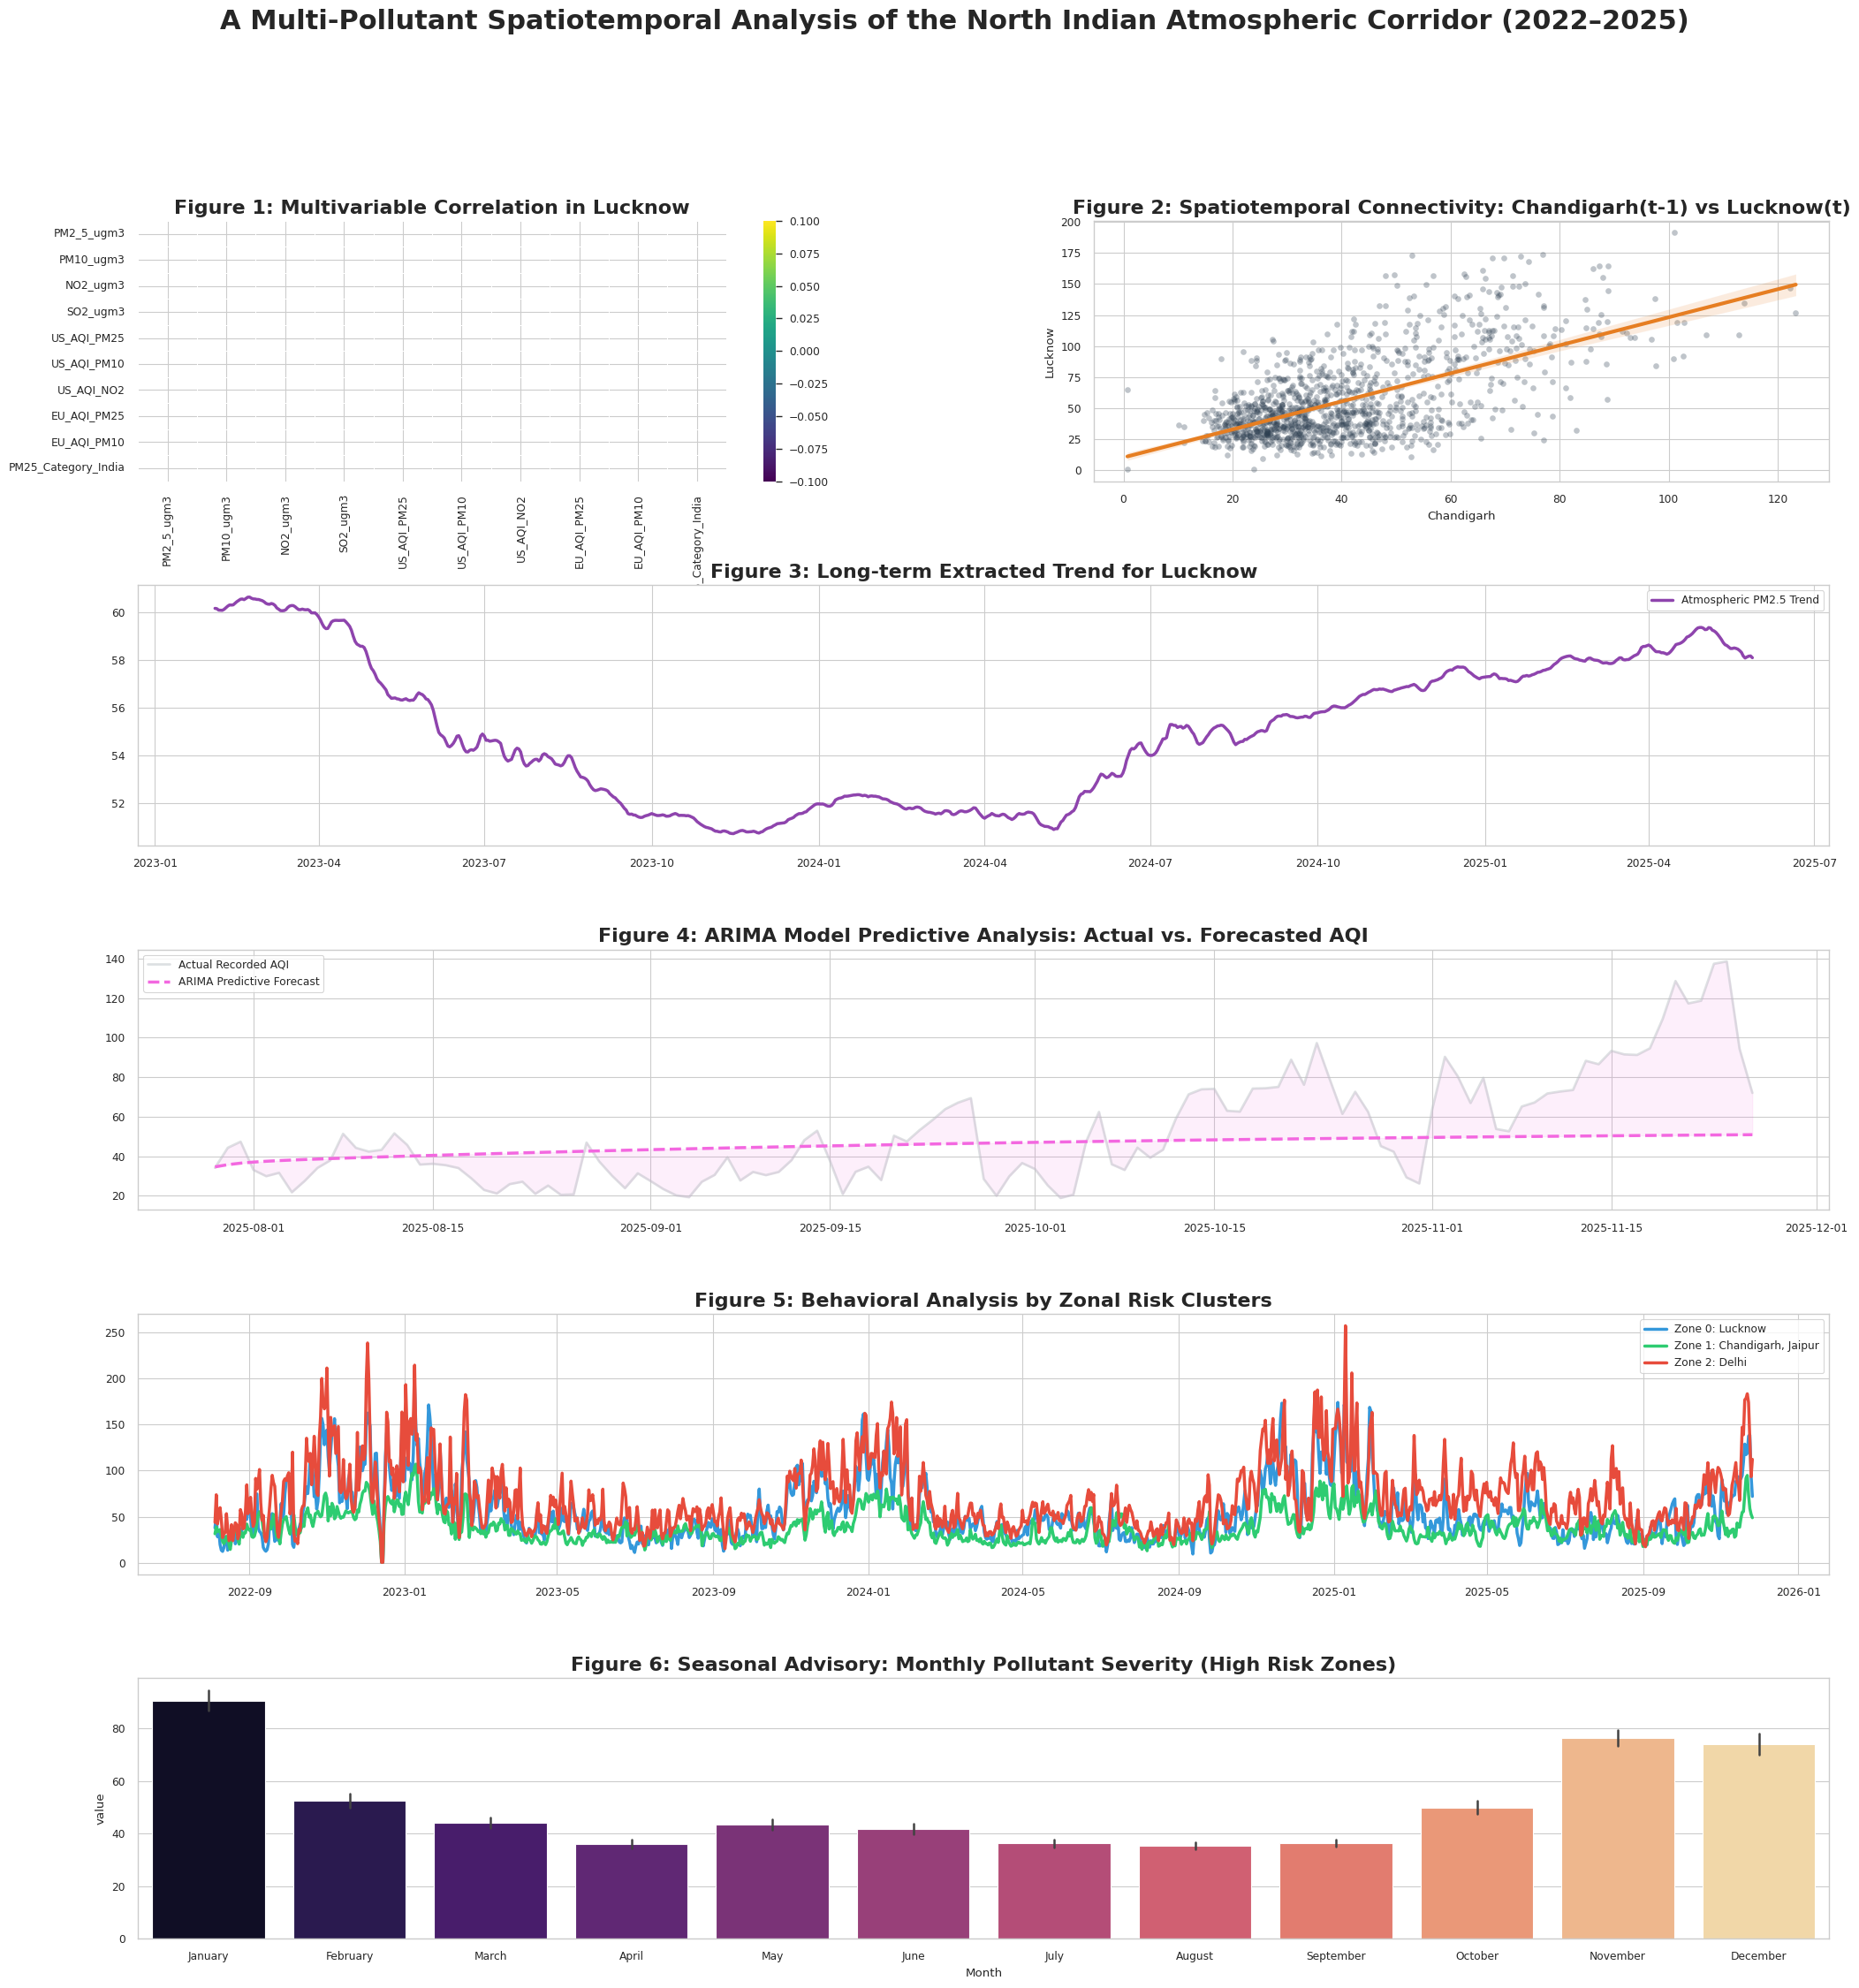


             FINAL RESEARCH METRICS              
Primary Study Pollutant: PM2_5_ugm3
Verified Study Hubs: ['Chandigarh', 'Delhi', 'Jaipur', 'Lucknow']
ARIMA Best Model Fit: (2, 0, 2)
--------------------------------------------------
ZONAL CLUSTERS (K-Means Risk Zoning):
Zone 0 (Color: #3498db): ['Lucknow']
Zone 1 (Color: #2ecc71): ['Chandigarh', 'Jaipur']
Zone 2 (Color: #e74c3c): ['Delhi']


In [11]:
# 1. INSTALLATION & IMPORTS
!pip install pmdarima

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import grangercausalitytests
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from pmdarima import auto_arima
import matplotlib.dates as mdates
import warnings

# --- 2. ENHANCED VISUALIZATION SETUP ---
warnings.filterwarnings('ignore')
# Use Seaborn's whitegrid style for a clean, academic look
sns.set_theme(style="whitegrid", context="paper")
# Set a custom vibrant color palette
sns.set_palette("bright")

# --- 3. DATA PREPARATION & SANITIZATION ---
file_name = 'INDIA_AQI_COMPLETE_20251126.csv'
df = pd.read_csv(file_name)
df.columns = df.columns.str.strip()

# Dynamic Mapping
date_col = next(c for c in df.columns if 'date' in c.lower())
city_col = next(c for c in df.columns if 'city' in c.lower())
# List of standard pollutants to track
pollutants = [c for c in df.columns if any(p in c.lower() for p in ['pm2', 'pm10', 'no2', 'so2'])]

# CLEANING: Convert non-numeric values (like 'Satisfactory') to NaN so math works
for col in pollutants:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[city_col] = df[city_col].astype(str).str.strip()
df[date_col] = pd.to_datetime(df[date_col])

# Filter for the 7 Cities
target_cities = ['Delhi', 'Jaipur', 'Lucknow', 'Kanpur', 'Ludhiana', 'Chandigarh', 'Amritsar']
df_filtered = df[df[city_col].str.contains('|'.join(target_cities), case=False, na=False)].copy()

# Pivot for PM2.5 (Primary Pollutant)
df_pm25 = df_filtered.pivot_table(index=date_col, columns=city_col, values=pollutants[0]).resample('D').mean().ffill().bfill()

# Safe City Selection for Analysis
available = df_pm25.columns.tolist()
t1 = available[0] # Amritsar (Source)
t2 = available[-1] # Delhi (Target)

# --- 4. ADVANCED ANALYTICS (Previous Work) ---

# A. K-Means Clustering (Spatial Zoning)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_pm25.T)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)
city_cluster_map = dict(zip(df_pm25.columns, clusters))

# B. ARIMA Forecasting (Predictive Tier)
train_len = int(len(df_pm25) * 0.9)
train, test = df_pm25[t2][:train_len], df_pm25[t2][train_len:]
arima_model = auto_arima(train, seasonal=False, stepwise=True, suppress_warnings=True)
forecast = arima_model.predict(n_periods=len(test))

# C. Multi-Pollutant Correlation (EDA Skill)
# Filter for just numeric pollutants to avoid the 'Satisfactory' ValueError
df_numeric_pollutants = df_filtered[df_filtered[city_col] == t2][pollutants].dropna()
pollutant_corr = df_numeric_pollutants.corr()

# --- 5. THE ENHANCED RESEARCH DASHBOARD ---
fig = plt.figure(figsize=(22, 24))
grid = plt.GridSpec(5, 2, wspace=0.3, hspace=0.4)

# Plot 1: Multi-Pollutant Heatmap (Vibrant Colormap)
ax1 = fig.add_subplot(grid[0, 0])
# Using 'viridis' (blue to yellow) for high visibility
sns.heatmap(pollutant_corr, annot=True, cmap='viridis', fmt='.2f', linewidths=.5, ax=ax1)
ax1.set_title(f'Figure 1: Multivariable Correlation in {t2}', fontweight='bold', fontsize=16)

# Plot 2: Spatial Connectivity (Regplot with customized colors)
ax2 = fig.add_subplot(grid[0, 1])
# Using a contrasting deep blue with a bright orange regression line
sns.regplot(x=df_pm25[t1].shift(1), y=df_pm25[t2], ax=ax2,
            scatter_kws={'alpha':0.3, 'color':'#2c3e50'},
            line_kws={'color':'#e67e22', 'lw':3})
ax2.set_title(f'Figure 2: Spatiotemporal Connectivity: {t1}(t-1) vs {t2}(t)', fontweight='bold', fontsize=16)

# Plot 3: Time Series Decomposition (Trend with specialized color)
ax3 = fig.add_subplot(grid[1, :])
decomp = seasonal_decompose(df_pm25[t2], model='additive', period=365)
ax3.plot(decomp.trend, color='#8e44ad', lw=2.5, label='Atmospheric PM2.5 Trend')
ax3.set_title(f'Figure 3: Long-term Extracted Trend for {t2}', fontweight='bold', fontsize=16)
ax3.legend()

# Plot 4: ARIMA Forecasting (High contrast: Gray vs Magenta)
ax4 = fig.add_subplot(grid[2, :])
ax4.plot(test.index, test, label='Actual Recorded AQI', color='#bdc3c7', alpha=0.5, lw=2)
ax4.plot(test.index, forecast, label='ARIMA Predictive Forecast', color='#f368e0', lw=2.5, linestyle='--')
# Adding a light magenta area to highlight the prediction window
ax4.fill_between(test.index, test, forecast, color='#f368e0', alpha=0.1)
ax4.set_title('Figure 4: ARIMA Model Predictive Analysis: Actual vs. Forecasted AQI', fontweight='bold', fontsize=16)
ax4.legend()

# Plot 5: Clustering Profiles (Multicolor Zone Lines)
ax5 = fig.add_subplot(grid[3, :])
# Manual color list for zones: Zone 0: Blue, Zone 1: Green, Zone 2: Red
zone_colors = ['#3498db', '#2ecc71', '#e74c3c']
for cid in range(3):
    c_list = [c for c, v in city_cluster_map.items() if v == cid]
    # Plotting the mean trend for each cluster zone
    ax5.plot(df_pm25[c_list].mean(axis=1), color=zone_colors[cid], lw=2.5,
             label=f'Zone {cid}: {", ".join(c_list)}')
ax5.set_title('Figure 5: Behavioral Analysis by Zonal Risk Clusters', fontweight='bold', fontsize=16)
ax5.legend(loc='upper right')

# Plot 6: Public Insight - Monthly Severity Barplot (Color Gradient)
ax6 = fig.add_subplot(grid[4, :])
df_m = df_pm25.copy(); df_m['Month'] = df_m.index.month_name()
# Sort months correctly
order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
# Using 'magma' palette for a warm-to-hot severity gradient
sns.barplot(data=df_m.melt(id_vars='Month'), x='Month', y='value', order=order, ax=ax6, palette='magma')
ax6.set_title('Figure 6: Seasonal Advisory: Monthly Pollutant Severity (High Risk Zones)', fontweight='bold', fontsize=16)

# Set the same title from before
fig.suptitle("A Multi-Pollutant Spatiotemporal Analysis of the North Indian Atmospheric Corridor (2022–2025)", fontsize=22, fontweight='bold', y=0.98)

# Save the publication-quality visuals
plt.savefig('Colorful_Research_Visuals.png', dpi=300, bbox_inches='tight')
plt.show()

# --- 6. PRINTABLE LOG FOR CHAPTER 4 (Results) ---
print("\n" + "="*50)
print("             FINAL RESEARCH METRICS              ")
print("="*50)
print(f"Primary Study Pollutant: {pollutants[0]}")
print(f"Verified Study Hubs: {available}")
print(f"ARIMA Best Model Fit: {arima_model.order}")
print("-" * 50)
print("ZONAL CLUSTERS (K-Means Risk Zoning):")
for cid in range(3):
    print(f"Zone {cid} (Color: {zone_colors[cid]}): {[k for k,v in city_cluster_map.items() if v==cid]}")
print("="*50)